# CamemBERT Fine-tuning Pipeline

This notebook fine-tunes a **CamemBERT** model (a French-language BERT variant) for **binary sequence classification**: given a paragraph of text, predict whether it discusses politics or not.

The pipeline is divided into three main phases:
1. **Data preparation** — load annotated data, clean text, tokenize, split into train/validation sets.
2. **Fine-tuning** — load the pre-trained model, configure the optimizer, run the training loop with per-epoch validation.
3. **Inference** — apply the trained model to a large unlabelled dataset and save the positively classified paragraphs.

---
**Model card:** [`google bert`](https://huggingface.co/google-bert/bert-base-multilingual-cased)  
**Task:** Binary text classification (political / non-political)  
**Language:** French and English

## 0. Required Packages

Install all dependencies. Run this cell only once (e.g. in a fresh environment or Colab).

| Package | Role |
|---|---|
| `transformers` | CamemBERT model and tokenizer (Hugging Face) |
| `torch` | PyTorch deep-learning framework |
| `tf-keras` | Required by some Hugging Face utilities for padding sequences |
| `pytorch_pretrained_bert` | Provides `BertAdam` optimizer with warm-up schedule |
| `scikit-learn` | Train/validation split, evaluation metrics |
| `matplotlib` / `seaborn` | Visualisation of training loss and confusion matrix |
| `numpy` / `pandas` | Data manipulation |

In [4]:
!pip install transformers
!pip install torch
!pip install scikit-learn
!pip install matplotlib
!pip install numpy
!pip install seaborn
!pip install krippendorff

## 1. Imports

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
import torch.optim as optim
from tqdm import tqdm, trange
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)
import pandas as pd
import io
import csv
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
import krippendorff

---
## 2. Data Preparation

### 2.1 Load and label the annotated dataset

In [51]:
CLASS_NAMES = ["political", "no political"]  # binary
label2id = {"political": 1, "no political": 0}
id2label = {v: k for k, v in label2id.items()}

# ── Load the three annotation datasets ──────────────────────────────────────

# Dataset 1: has text and labels but lost its 'id' column
df_ann1_1 = pd.read_csv("bert/annotations_train_1.csv")
df_ann1_2 = pd.read_csv("bert/annotations_train_1_2.csv")

df_ann1=pd.concat([df_ann1_1,df_ann1_2])
# columns: id_internal, dataset, dataset_annotation, labels, user, timestamp, comment, text, dataset_row_number
df_ann1['labels'] = df_ann1['labels'].replace('non political', 'no political')
# Dataset 2: standard format
df_ann2 = pd.read_csv("bert/annotations_train_2.csv")
# columns: Unnamed: 0, id, type, text, annotation

# Dataset 3: same structure, different column name
df_ann3 = pd.read_csv("bert/annotations_train_3.csv", delimiter=";")
# columns: 0, id, type, text, annotations

# ── Dataset 4: recover missing ids for dataset 1 ────────────────────────────
# Dataset 4 has id + text but no annotations
df_ref_1 = pd.read_csv("bert/references.csv")
df_ref_2 = pd.read_csv("bert/references_2.csv")

df_ref=pd.concat([df_ref_1,df_ref_2])
# columns: , id, type, text

# Merge on text to recover the id column for df_ann1
df_ann1 = df_ann1.merge(df_ref[['id', 'text']], on='text', how='left')
n_unmatched = df_ann1['id'].isna().sum()
if n_unmatched > 0:
    print(f"⚠️  {n_unmatched} rows in dataset 1 could not be matched to an id via text.")
else:
    print("✅ All rows in dataset 1 successfully matched to an id.")

# ── Normalise to a common schema: id, text, label ───────────────────────────
df_ann1_norm = df_ann1[['id', 'text', 'labels']].rename(columns={'labels': 'label'})
df_ann1_norm['annotator'] = 'annotator_1'

df_ann2_norm = df_ann2[['id', 'text', 'annotation']].rename(columns={'annotation': 'label'})
df_ann2_norm['annotator'] = 'annotator_2'

df_ann3_norm = df_ann3[['id', 'text', 'annotations']].rename(columns={'annotations': 'label'})
df_ann3_norm['annotator'] = 'annotator_3'

df_all = pd.concat([df_ann1_norm, df_ann2_norm, df_ann3_norm], axis=0, ignore_index=True)

# Sanity check: label values
print("\nUnique label values across all datasets:")
print(df_all['label'].value_counts())

✅ All rows in dataset 1 successfully matched to an id.

Unique label values across all datasets:
label
no political    1231
political        319
Name: count, dtype: int64


### 2.2 Inter coder agreement

In [52]:
print(df_pivot.index.dtype)
print(df_ref['id'].dtype)
print(df_pivot.index[:5].tolist())
print(df_ref['id'][:5].tolist())

object
object
['2X0004244', '2X00101388', '2X00101938', '2X0010621', '2X00254']
['3X0210122', '3X0017683', '3X0884418', '3X0076304', '2X1519841']


In [53]:
import krippendorff
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

# ── Pivot to wide format: one row per id, one column per annotator ───────────
df_pivot = df_all.pivot_table(index='id', columns='annotator', values='label', aggfunc='first')

# Only keep ids that were annotated by at least 2 annotators
df_overlap = df_pivot.dropna(thresh=2)
print(f"Items annotated by ≥2 annotators: {len(df_overlap)}")
print(f"Items annotated by all 3:          {df_overlap.dropna().shape[0]}")

annotators = df_pivot.columns.tolist()

# ── 1. Percent agreement ─────────────────────────────────────────────────────
def percent_agreement(df_wide):
    """Fraction of items where all available annotators agree."""
    agree = df_wide.apply(lambda row: row.dropna().nunique() == 1, axis=1)
    return agree.mean()

pct = percent_agreement(df_overlap)
print(f"\nPercent agreement (≥2 annotators): {pct:.3f}")

# ── 2. Cohen's Kappa (pairwise) ──────────────────────────────────────────────
print("\nCohen's Kappa (pairwise):")
for a1, a2 in combinations(annotators, 2):
    pair = df_pivot[[a1, a2]].dropna()
    if len(pair) < 2:
        print(f"  {a1} vs {a2}: not enough overlap")
        continue
    kappa = cohen_kappa_score(pair[a1], pair[a2])
    print(f"  {a1} vs {a2}: κ = {kappa:.4f}  (n={len(pair)})")

text_lookup = df_all[['id', 'text']].drop_duplicates(subset='id')

all_disagreements = []
for a1, a2 in combinations(annotators, 2):
    pair = df_pivot[[a1, a2]].dropna().reset_index()
    disagreements = pair[pair[a1] != pair[a2]].copy()
    disagreements['pair'] = f"{a1}_vs_{a2}"
    all_disagreements.append(disagreements)

df_disagreements = pd.concat(all_disagreements, ignore_index=True)
df_disagreements = df_disagreements.merge(text_lookup, on='id', how='left')
df_disagreements.to_csv("disagreements.csv", index=False)
print(f"✅ {len(df_disagreements)} disagreements saved to disagreements.csv")

# ── 3. Krippendorff's Alpha ──────────────────────────────────────────────────
# Encode labels as integers for krippendorff library
label_encoder = {cat: i for i, cat in enumerate(categories)}
reliability_data = df_overlap.applymap(
    lambda x: label_encoder[x] if pd.notna(x) else np.nan
).values.T  # shape: (annotators, items)

alpha = krippendorff.alpha(reliability_data, level_of_measurement='nominal')
print(f"\nKrippendorff's Alpha (nominal, n={len(df_overlap)}): α = {alpha:.4f}")

# ── Interpretation guide ─────────────────────────────────────────────────────
print("""
Agreement interpretation (Kappa / Alpha):
  < 0.20  : Slight
  0.20–0.40: Fair
  0.40–0.60: Moderate
  0.60–0.80: Substantial
  > 0.80  : Almost perfect
""")

Items annotated by ≥2 annotators: 205
Items annotated by all 3:          1

Percent agreement (≥2 annotators): 0.878

Cohen's Kappa (pairwise):
  annotator_1 vs annotator_2: κ = 0.6310  (n=69)
  annotator_1 vs annotator_3: κ = 0.5421  (n=67)
  annotator_2 vs annotator_3: κ = 0.7051  (n=71)
✅ 26 disagreements saved to disagreements.csv

Krippendorff's Alpha (nominal, n=205): α = 0.6394

Agreement interpretation (Kappa / Alpha):
  < 0.20  : Slight
  0.20–0.40: Fair
  0.40–0.60: Moderate
  0.60–0.80: Substantial
  > 0.80  : Almost perfect



/tmp/ipykernel_2266/4049924193.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reliability_data = df_overlap.applymap(


### 2.3 Final dataset

In [54]:
# ── Keep only items where ALL annotators who labelled it agree ───────────────
def is_unanimous(row):
    values = row.dropna()
    return len(values) >= 1 and values.nunique() == 1

unanimous_mask = df_pivot.apply(is_unanimous, axis=1)
df_agreed = df_pivot[unanimous_mask].copy()

# Extract the agreed label (first non-null value, all are identical)
df_agreed['label'] = df_agreed.apply(lambda row: row.dropna().iloc[0], axis=1)
df_agreed = df_agreed[['label']].reset_index()  # columns: id, label

# Merge back text from the reference dataset
df_agreed = df_agreed.merge(df_all[['id', 'text']], on='id', how='left')

# Binarise label
df_agreed['label'] = df_agreed['label'].map(label2id)

# Final annotations dataframe — drop-in replacement for the original `annotations`
annotations = df_agreed[['text', 'label']].rename(columns={'label': 'political'})
print(annotations.head(10))
print(f"Total annotated items:         {len(df_pivot)}")
print(f"Items with unanimous agreement:{unanimous_mask.sum()} ({unanimous_mask.mean():.1%})")
print(f"Items discarded (disagreement):{(~unanimous_mask).sum()}")
print(f"\nFinal training set class distribution:")
print(annotations['political'].value_counts())

                                                text  political
0  Oh they're so cute, they look way less like al...          0
1  At some points in the game I couldn't help mys...          0
2                                          [removed]          0
3                                          [removed]          0
4                                          [removed]          0
5                                          [removed]          0
6  Pour moi la position de ces gens manque cruell...          1
7  Hey, you can't turn into a murder monstrosity ...          0
8  Et qui serait le juge ? Imagine qu'on soit pas...          1
9  Si la paix avait pu être négociée plus tôt, le...          1
Total annotated items:         1247
Items with unanimous agreement:1222 (98.0%)
Items discarded (disagreement):25

Final training set class distribution:
political
0    1206
1     293
Name: count, dtype: int64


### 2.4 Text cleaning

The raw text contains residual **HTML entities** (e.g. `&eacute;` for `é`) and paragraph tags (`</P> <P>`) inherited from the source documents. These need to be normalised before tokenization because:
- The tokenizer's vocabulary is built on clean French text; feeding HTML entities would cause them to be split into unusual sub-word tokens.
- Paragraph separators should be replaced by a space so that the text is read as continuous prose.

> **Note:** This is a hand-crafted replacement dictionary. If the source data changes format, this function should be revisited. An alternative would be to use a library such as `html` (`html.unescape`) for standard HTML entities.

In [55]:
def clean_paragraph_text(text):
    """Decode HTML entities and remove paragraph tags from a text string.
    
    Returns the original value unchanged if it is NaN (missing).
    """
    if pd.isna(text):
        return text  # Preserve NaNs; they will be caught downstream if needed

    replacements = {
        "&eacute;": "é",
        "&agrave;": "à",
        "&egrave;": "è",
        "&Icirc;": "Î",
        "&ccedil;": "ç",
        "&acirc;": "â",
        "</P> <P>": " ",   # Merge adjacent paragraph blocks into a single string
    }

    for key, val in replacements.items():
        text = text.replace(key, val)

    return text

In [56]:
# Apply cleaning in-place on the 'text' column
annotations['text'] = annotations['text'].apply(clean_paragraph_text)

# Sanity check: ensure no NaN values remain in the text column before tokenization
n_missing = annotations['text'].isna().sum()
if n_missing > 0:
    print(f"⚠️  Warning: {n_missing} missing text values detected. Consider dropping or filling them.")
else:
    print("✅ No missing text values.")

⚠️  Warning: 1 missing text values detected. Consider dropping or filling them.


In [57]:
annotations = annotations.dropna(subset=['text']).reset_index(drop=True)

### 2.3 Tokenization

CamemBERT uses a **SentencePiece BPE tokenizer**. Each text is converted into a sequence of integer token IDs that the model can process.

**Key hyperparameter — `MAX_LEN = 512`**
- BERT-family models have a hard limit of **512 tokens** per input sequence. This is an architectural constraint of the positional embeddings.
- Sequences shorter than 512 are **padded** (with a special `[PAD]` token) to reach `MAX_LEN`.
- Sequences longer than 512 are **truncated** from the right. If your paragraphs are very long, consider splitting them before tokenization to avoid information loss.

**Attention mask:** A binary tensor of shape `(N, MAX_LEN)` where `1` indicates a real token and `0` indicates a padding token. This prevents the model from attending to padding positions.

In [58]:
# ── Hyperparameter ────────────────────────────────────────────────────────────
MAX_LEN = 512  # Maximum sequence length for CamemBERT (hard architectural limit)
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")

encodings = tokenizer(
    list(annotations['text']),
    max_length=MAX_LEN,
    padding='max_length',      # Pad all sequences to MAX_LEN
    truncation=True,           # Truncate sequences exceeding MAX_LEN
    return_tensors='pt',       # Return PyTorch tensors directly
    return_attention_mask=True # Generate attention masks
)

input_ids      = encodings['input_ids']       # shape: (N, MAX_LEN)
attention_masks = encodings['attention_mask'] # shape: (N, MAX_LEN)

print(f"input_ids shape:       {input_ids.shape}")
print(f"attention_masks shape: {attention_masks.shape}")

input_ids shape:       torch.Size([1498, 512])
attention_masks shape: torch.Size([1498, 512])


### 2.4 Train / Validation split

**Hyperparameter — `test_size = 0.15`**
- 85 % of data goes to the training set; 15 % is held out for validation.
- A 80/20 or 85/15 split is standard for fine-tuning on small annotated corpora.
- `random_state=2018` ensures reproducibility.

> ⚠️ **Important:** the same `random_state` must be used for both the `(input_ids, labels)` split **and** the `(attention_masks, ...)` split so that each input sequence is paired with its correct mask. The dummy second array passed to the second `train_test_split` call (`input_ids`) is used only to enforce the same stratified split; its result is discarded (`_`).

> **Validation correctness:** The validation set is used *only for monitoring* — it is never seen during the gradient updates. This gives an unbiased estimate of generalisation at the end of each epoch. If you wanted a fully independent test set, you should set aside a third split before this step.

In [59]:
labels = torch.tensor(annotations.political.values)

# ── Hyperparameter ────────────────────────────────────────────────────────────
VALIDATION_SPLIT = 0.2  # 15 % held out for validation
RANDOM_SEED      = 2018  # Fixed seed for reproducibility
# ─────────────────────────────────────────────────────────────────────────────

# Split input IDs and labels
train_inputs_raw, validation_inputs_raw, \
train_labels_raw, validation_labels_raw = train_test_split(
    input_ids, labels,
    random_state=RANDOM_SEED,
    test_size=VALIDATION_SPLIT
)

# Split attention masks using the SAME random state so mask[i] matches input[i]
train_masks_raw, validation_masks_raw, _, _ = train_test_split(
    attention_masks, input_ids,
    random_state=RANDOM_SEED,
    test_size=VALIDATION_SPLIT
)

# Convert to tensors (input_ids and attention_masks are already tensors;
# torch.tensor() on a tensor returns a copy — this is safe but redundant;
# using .clone() would be more explicit)
train_inputs      = torch.tensor(train_inputs_raw)
validation_inputs = torch.tensor(validation_inputs_raw)
train_labels      = torch.tensor(train_labels_raw)
validation_labels = torch.tensor(validation_labels_raw)
train_masks       = torch.tensor(train_masks_raw)
validation_masks  = torch.tensor(validation_masks_raw)

print(f"Training set size:   {len(train_inputs)}")
print(f"Validation set size: {len(validation_inputs)}")

/tmp/ipykernel_2266/2242392137.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_inputs      = torch.tensor(train_inputs_raw)
/tmp/ipykernel_2266/2242392137.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  validation_inputs = torch.tensor(validation_inputs_raw)
/tmp/ipykernel_2266/2242392137.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels      = torch.tensor(train_labels_raw)
/tmp/ipykernel_2266/2242392137.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clo

Training set size:   1198
Validation set size: 300


### 2.5 DataLoaders

PyTorch `DataLoader` objects wrap a `TensorDataset` and serve mini-batches during training. They handle shuffling and memory efficiency by loading only one batch at a time.

**Hyperparameter — `batch_size = 16`**
- The original BERT paper recommends **16 or 32** for fine-tuning.
- Smaller batches use less GPU memory but introduce noisier gradient estimates.
- If you have a GPU with ≥16 GB VRAM, batch size 32 is reasonable. On smaller GPUs, use 16 or 8 with gradient accumulation.

**Sampler choice:**
- `RandomSampler` for **training** — shuffles the data each epoch to prevent the model from learning the ordering of examples.
- `SequentialSampler` for **validation** — order does not matter for evaluation, and sequential access is slightly faster.

In [60]:
# ── Hyperparameter ────────────────────────────────────────────────────────────
BATCH_SIZE = 16  # Standard for BERT fine-tuning (original paper: 16 or 32)
# ─────────────────────────────────────────────────────────────────────────────

# Training DataLoader — randomly shuffled each epoch
train_data       = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler    = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=BATCH_SIZE)

# Validation DataLoader — sequential order (no shuffling needed for evaluation)
validation_data       = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler    = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=BATCH_SIZE)

print(f"Training batches:   {len(train_dataloader)}")
print(f"Validation batches: {len(validation_dataloader)}")

Training batches:   75
Validation batches: 19


---
## 3. Model Setup

### 3.1 Load CamemBERT and configure the optimizer

**`CamembertForSequenceClassification`** adds a linear classification head on top of the CamemBERT encoder. The head maps the `[CLS]` token's hidden state (dim 768) to `num_labels` logits.

**Optimizer — `BertAdam`**
- A variant of Adam specifically designed for BERT fine-tuning. It includes a **linear warm-up** phase and a **weight-decay** schedule.
- Weight decay is applied to all parameters **except** biases, LayerNorm gain (`gamma`) and bias (`beta`) — this is the standard BERT regularisation practice, as decaying these parameters tends to hurt performance.

**Key hyperparameters:**

| Hyperparameter | Value | Rationale |
|---|---|---|
| `lr` | `1e-5` | The original BERT paper recommends 2e-5 to 5e-5. Lower values (1e-5) reduce the risk of catastrophic forgetting of pre-trained weights. |
| `warmup` | `0.1` | 10 % of total steps used for warm-up; the learning rate rises linearly then decays. Standard practice for BERT fine-tuning. |
| `weight_decay_rate` | `0.01` | Applied to non-bias parameters. Prevents overfitting. |
| `epochs` | `4` | The original BERT paper recommends **2–4** epochs for fine-tuning. More epochs risk overfitting on small datasets. |

In [61]:
MODEL_NAME = "EuroBERT/EuroBERT-210m"  # or EuroBERT-610m / EuroBERT-2.1B

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

# ── Optimizer — AdamW (replaces BertAdam) ───────────────────────────────────
# Same weight-decay logic: no decay on biases and LayerNorm parameters
no_decay = ['bias', 'norm']   # EuroBERT uses 'norm' instead of 'gamma'/'beta'
param_optimizer = list(model.named_parameters())

optimizer_grouped_parameters = [
    {
        'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01
    },
    {
        'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

# ── Hyperparameters ─────────────────────────────────────────────────────────
LEARNING_RATE = 3e-5
WARMUP_RATIO  = 0.1
EPOCHS        = 3
# ────────────────────────────────────────────────────────────────────────────

optimizer = optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)

# Warmup scheduler — replaces BertAdam's built-in warmup argument
total_steps    = len(train_dataloader) * EPOCHS
warmup_steps   = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

train_loss_set = []
print(f"Total training steps: {total_steps} | Warmup steps: {warmup_steps}")

Loading weights: 100%|██████████| 110/110 [00:00<00:00, 13015.13it/s]
EuroBertForSequenceClassification LOAD REPORT from: EuroBERT/EuroBERT-210m
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
dense.weight      | MISSING    | 
dense.bias        | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 225 | Warmup steps: 22


### 3.2 Helper function and device detection

In [62]:
def flat_accuracy(preds, labels):
    """Compute flat accuracy between argmax predictions and integer labels.
    
    Args:
        preds  : np.ndarray of shape (batch_size, num_labels) — raw logits or probabilities
        labels : np.ndarray of shape (batch_size,) — integer ground-truth labels
    
    Returns:
        float: fraction of correct predictions in this batch
    """
    pred_flat   = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


# Detect hardware: prefer GPU (CUDA) for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  GPU not available. Using CPU — training will be significantly slower.")

⚠️  GPU not available. Using CPU — training will be significantly slower.


---
## 4. Training Loop

Each epoch consists of two phases:

1. **Training phase** (`model.train()`)
   - Batches are iterated from the shuffled `train_dataloader`.
   - For each batch: forward pass → compute cross-entropy loss → backward pass → optimizer step.
   - `optimizer.zero_grad()` is called **before** the forward pass to clear accumulated gradients from the previous step.

2. **Validation phase** (`model.eval()`)
   - `torch.no_grad()` disables gradient computation, reducing memory usage and speeding up inference.
   - Accuracy is accumulated across all validation batches and averaged.
   - **No weight updates occur during validation** — this is correct behaviour.

> **Validation correctness note:** The per-epoch validation accuracy reported here is an *in-training monitor*, not a final test score. The validation set was split before training and is never used for gradient updates, so it provides a genuine estimate of generalisation. However, if hyperparameters (e.g. `epochs`, `lr`) are tuned based on this metric, a separate held-out test set would be needed for an unbiased final evaluation.

In [63]:
model.to(device)

for epoch in trange(EPOCHS, desc="Epoch"):

    # ── Phase 1: Training ─────────────────────────────────────────────────────
    model.train()  # Activates dropout and BatchNorm in training mode

    tr_loss = 0
    nb_tr_examples, nb_tr_steps = 0, 0

    for step, batch in enumerate(train_dataloader):
        # Move batch tensors to the selected device (GPU or CPU)
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        # Clear gradients from the previous step before computing new ones
        optimizer.zero_grad()

        # Forward pass: model computes logits and cross-entropy loss when
        # `labels` is provided
        outputs = model(
            b_input_ids,
            token_type_ids=None,        # CamemBERT is single-segment; no token type IDs needed
            attention_mask=b_input_mask,
            labels=b_labels
        )
        loss = outputs.loss
        train_loss_set.append(loss.item())  # Record for plotting

        # Backward pass: compute gradients with respect to all parameters
        loss.backward()

        # Update parameters using the computed gradients
        optimizer.step()
        scheduler.step()

        tr_loss        += loss.item()
        nb_tr_examples += b_input_ids.size(0)
        nb_tr_steps    += 1

    print("  Train loss: {:.4f}".format(tr_loss / nb_tr_steps))

    # ── Phase 2: Validation ───────────────────────────────────────────────────
    model.eval()  # Deactivates dropout — essential for deterministic evaluation

    eval_accuracy = 0
    nb_eval_steps = 0

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        # Disable gradient tracking during validation to save memory and compute
        with torch.no_grad():
            outputs = model(
                b_input_ids,
                token_type_ids=None,
                attention_mask=b_input_mask
                # No `labels` here: we do not want the model to compute a loss
                # on the validation set (no weight updates should happen)
            )
            logits = outputs.logits  # shape: (batch_size, 2)

        logits    = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        eval_accuracy += flat_accuracy(logits, label_ids)
        nb_eval_steps += 1

    print("  Validation Accuracy: {:.4f}".format(eval_accuracy / nb_eval_steps))

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

  Train loss: 0.4162


Epoch:  33%|███▎      | 1/3 [1:34:34<3:09:08, 5674.35s/it]

  Validation Accuracy: 0.8311
  Train loss: 0.2634


Epoch:  67%|██████▋   | 2/3 [2:15:42<1:03:08, 3788.09s/it]

  Validation Accuracy: 0.9156
  Train loss: 0.0820


Epoch: 100%|██████████| 3/3 [3:03:45<00:00, 3675.08s/it]  

  Validation Accuracy: 0.9189


---
## 5. Training Diagnostics

### 5.1 Training loss curve

The loss is recorded **per batch** (not per epoch), so the x-axis represents the number of gradient update steps. A healthy training curve shows a generally decreasing trend with some noise due to batch-level stochasticity.

**What to look for:**
- A monotonically decreasing curve suggests the model is learning.
- If the loss plateaus early, the learning rate may be too low or the model may have converged.
- If the loss diverges or oscillates wildly, the learning rate may be too high.

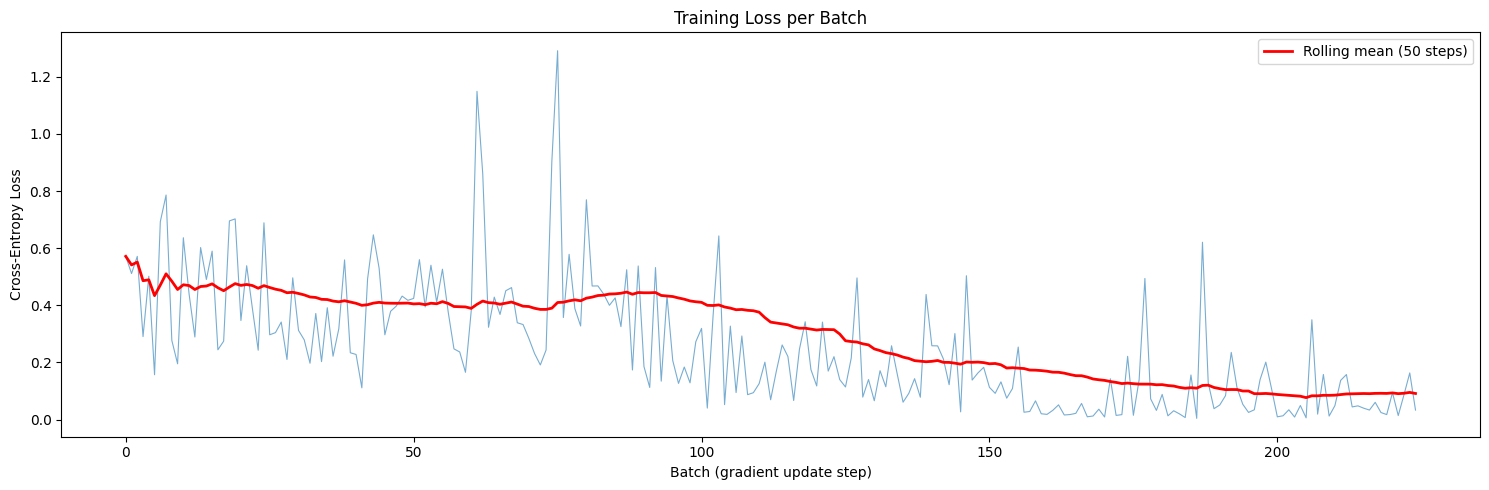

In [64]:
plt.figure(figsize=(15, 5))
plt.title("Training Loss per Batch")
plt.xlabel("Batch (gradient update step)")
plt.ylabel("Cross-Entropy Loss")
plt.plot(train_loss_set, alpha=0.6, linewidth=0.8)
# Overlay a smoothed trend line (rolling mean over 50 steps)
if len(train_loss_set) > 50:
    smooth = pd.Series(train_loss_set).rolling(50, min_periods=1).mean()
    plt.plot(smooth, color='red', linewidth=2, label='Rolling mean (50 steps)')
    plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Confusion matrix and classification report on the validation set

The confusion matrix breaks down the model's predictions into four quadrants:
- **True Positive (TP):** correctly predicted *chômage*
- **True Negative (TN):** correctly predicted *non-chômage*
- **False Positive (FP):** predicted *chômage* but actually not (Type I error)
- **False Negative (FN):** predicted *non-chômage* but actually *chômage* (Type II error)

The `classification_report` provides **precision**, **recall** and **F1-score** per class, which are more informative than raw accuracy when the classes are imbalanced.

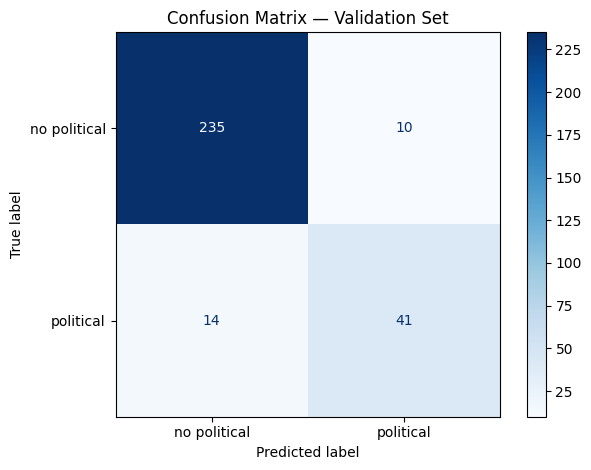

📊 Classification Report (validation set):
              precision    recall  f1-score   support

no political     0.9438    0.9592    0.9514       245
   political     0.8039    0.7455    0.7736        55

    accuracy                         0.9200       300
   macro avg     0.8738    0.8523    0.8625       300
weighted avg     0.9181    0.9200    0.9188       300

✅ Overall Accuracy: 0.92


In [65]:
# ── Generate predictions on the validation set ────────────────────────────────
model.eval()
all_preds = []

for batch in validation_dataloader:
    input_ids_batch, attention_mask_batch, _ = tuple(t.to(device) for t in batch)
    with torch.no_grad():
        outputs = model(input_ids_batch, attention_mask=attention_mask_batch)
        logits  = outputs.logits                  # shape: (batch_size, 2)
        preds   = torch.argmax(logits, dim=1)     # shape: (batch_size,)
        all_preds.extend(preds.cpu().numpy())

# ── Assemble results dataframe ────────────────────────────────────────────────
val_results = pd.DataFrame({
    "true_labels": validation_labels_raw.tolist(),
    "pred_labels": all_preds
})

true_labels = val_results["true_labels"].values
pred_labels = val_results["pred_labels"].values

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no political", "political"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.show()

# ── Detailed metrics ──────────────────────────────────────────────────────────
print("📊 Classification Report (validation set):")
print(classification_report(
    true_labels, pred_labels,
    target_names=["no political", "political"],
    digits=4
))
print("✅ Overall Accuracy:", accuracy_score(true_labels, pred_labels))

---
## 6. Save the Fine-tuned Model

`save_pretrained` serialises both the model weights and its configuration to a local directory. The tokenizer is saved alongside so that it can be reloaded identically for inference.

This is the standard Hugging Face pattern for saving fine-tuned models. The directory can later be passed directly to `from_pretrained()` instead of a HuggingFace Hub identifier.

In [66]:
MODEL_SAVE_PATH = "model_eurobert_political_1"

model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f"✅ Model and tokenizer saved to './{MODEL_SAVE_PATH}/'")

Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.73s/it]


✅ Model and tokenizer saved to './model_eurobert_political_1/'
